In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# viscosity - Forward N - total N
# 2.1-103-104
# 2.0-102-103
# 1.9-104-105
# 1.8-96-103
# 1.7-94-112
# 1.6-75-104
# 1.5-77-101
# 1.4-80-104
# 1.3-78-101
# 1.2-77-104
# 1.1-82-104
# 1.0-81-105
# 0.9-80-104


In [3]:
viscosity = np.array([2.1, 2.0, 1.9, 1.8, 1.7, 1.6, 1.5, 1.4, 1.3, 1.2, 1.1, 1.0, 0.9])
forward_N = np.array([103, 102, 104, 96, 94, 75, 77, 80, 78, 77, 82, 81, 80])
total_N = np.array([104, 103, 105, 103, 112, 104, 101, 104, 101, 104, 104, 105, 104])

color = 'k'

# calculate fraction of backward (1 - forward_N/total_N)
fraction_backward = 1 - forward_N / total_N
# SE of proportion (standard error of the proportion)
se_proportion = np.sqrt((fraction_backward * (1 - fraction_backward)) / total_N)


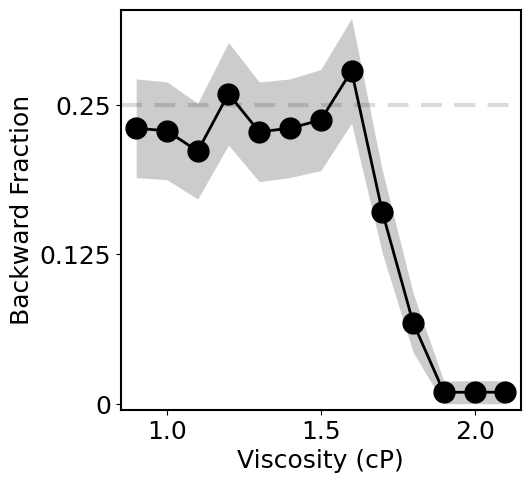

In [4]:
# Compute backward fraction and SE
fraction_backward = 1 - forward_N / total_N
se_proportion = np.sqrt((fraction_backward * (1 - fraction_backward)) / total_N)


# Create figure
plt.figure(figsize=(5, 3.5))

# Plot line
plt.plot(viscosity, fraction_backward, 'o-', color=color, label='Fraction Backward', markersize=15, linewidth=2)

# # plot dots
# plt.plot(viscosity, fraction_backward, 'o', color=color, markersize=15, label='Fraction Backward', linewidth=2)\

# add a dased line at 0.25
plt.axhline(y=0.25, color='lightgray', linestyle='--', linewidth=3, zorder=0, dashes=(5, 3), alpha = 0.8)

# Plot shaded SE area
plt.fill_between(viscosity,
                 fraction_backward - se_proportion,
                 fraction_backward + se_proportion,
                 color=color, alpha=0.2, linewidth=0)

# Axis settings
# plt.ylim(-0.02, 0.35)
plt.ylim(-0.005, 0.33)
plt.xlim(0.85, 2.15)
plt.xlabel('Viscosity (cP)')
plt.ylabel('Backward Fraction')

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=8)
# set yticks
# ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_yticks([0, 0.125, 0.25], ["0", "0.125", "0.25"])
# set xticks
ax.set_xticks([1, 1.5, 2])

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

set_size(4, 4)


## Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('viscosity_response_v4.7.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
